- Esse notebook servirá para fazer uma análise exploratória dos dados e tentar responder qualquer pergunta que eu tenha sobre a NFL.

In [10]:
ANO_ATUAL = 2026

ultimos_5_anos = list(range(ANO_ATUAL - 5, ANO_ATUAL))

In [11]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Baixando o calendário...")
df_jogos = nfl.load_schedules(ultimos_5_anos).to_pandas()

df_regular = df_jogos[df_jogos['game_type'] == 'REG']

print("Baixando estatísticas semanais de jardas e turnovers da API (pode levar alguns segundos)...")
df_stats = nfl.load_player_stats(ultimos_5_anos).to_pandas()

Baixando o calendário...
Baixando estatísticas semanais de jardas e turnovers da API (pode levar alguns segundos)...


In [12]:
display(df_regular)

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2021_01_DAL_TB,2021,REG,1,2021-09-09,Thursday,20:20,DAL,29,TB,...,9.0,00-0033077,00-0019596,Dak Prescott,Tom Brady,Mike McCarthy,Bruce Arians,Shawn Hochuli,TAM00,Raymond James Stadium
1,2021_01_PHI_ATL,2021,REG,1,2021-09-12,Sunday,13:00,PHI,32,ATL,...,NaN,00-0036389,00-0026143,Jalen Hurts,Matt Ryan,Nick Sirianni,Arthur Smith,Scott Novak,ATL97,Mercedes-Benz Stadium
2,2021_01_PIT_BUF,2021,REG,1,2021-09-12,Sunday,13:00,PIT,23,BUF,...,17.0,00-0022924,00-0034857,Ben Roethlisberger,Josh Allen,Mike Tomlin,Sean McDermott,John Hussey,BUF00,New Era Field
3,2021_01_NYJ_CAR,2021,REG,1,2021-09-12,Sunday,13:00,NYJ,14,CAR,...,0.0,00-0037013,00-0034869,Zach Wilson,Sam Darnold,Robert Saleh,Matt Rhule,Clay Martin,CAR00,Bank of America Stadium
4,2021_01_MIN_CIN,2021,REG,1,2021-09-12,Sunday,13:00,MIN,24,CIN,...,15.0,00-0029604,00-0036442,Kirk Cousins,Joe Burrow,Mike Zimmer,Zac Taylor,Adrian Hill,CIN00,Paul Brown Stadium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,2025_18_DAL_NYG,2025,REG,18,2026-01-04,Sunday,13:00,DAL,17,NYG,...,7.0,00-0033077,00-0040691,Dak Prescott,Jaxson Dart,Brian Schottenheimer,Brian Daboll,Adrian Hill,NYC01,MetLife Stadium
1407,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,9.0,00-0026300,00-0038400,Josh Johnson,Tanner McKee,Dan Quinn,Nick Sirianni,Shawn Hochuli,PHI00,Lincoln Financial Field
1408,2025_18_BAL_PIT,2025,REG,18,2026-01-04,Sunday,20:20,BAL,24,PIT,...,3.0,00-0034796,00-0023459,Lamar Jackson,Aaron Rodgers,John Harbaugh,Mike Tomlin,Shawn Smith,PIT00,Acrisure Stadium
1409,2025_18_SEA_SF,2025,REG,18,2026-01-03,Saturday,20:00,SEA,13,SF,...,8.0,00-0034869,00-0037834,Sam Darnold,Brock Purdy,Mike Macdonald,Kyle Shanahan,Bill Vinovich,SFO01,Levi's Stadium


In [13]:
display(df_stats)

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,game_id,...,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
0,00-0019596,T.Brady,Tom Brady,QB,QB,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_DAL_TB,...,0,0,0,0,0,0,0,0,27.16,27.16
1,00-0022824,A.Lee,Andy Lee,P,SPEC,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_ARI_TEN,...,0,1,1,1,0,0,0,124,0.00,0.00
2,00-0022924,B.Roethlisberger,Ben Roethlisberger,QB,QB,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_PIT_BUF,...,0,0,0,0,0,0,0,0,12.02,12.02
3,00-0023252,R.Gould,Robbie Gould,K,SPEC,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_SF_DET,...,0,0,0,0,0,0,0,0,0.00,0.00
4,00-0023459,Aa.Rodgers,Aaron Rodgers,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2021,1,REG,2021_01_GB_NO,...,0,0,0,0,0,0,0,0,1.32,1.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94843,00-0040699,W.Campbell,Will Campbell,OT,OL,https://static.www.nfl.com/image/upload/f_auto...,2025,22,POST,2025_22_SEA_NE,...,0,0,0,0,0,0,0,0,0.00,0.00
94844,00-0040716,C.Woodson,Craig Woodson,SAF,DB,https://static.www.nfl.com/image/upload/f_auto...,2025,22,POST,2025_22_SEA_NE,...,0,0,0,0,0,0,0,0,0.00,0.00
94845,00-0040733,N.Emmanwori,Nick Emmanwori,SAF,DB,https://static.www.nfl.com/image/upload/f_auto...,2025,22,POST,2025_22_SEA_NE,...,0,0,0,0,0,0,0,0,0.00,0.00
94846,00-0040734,T.Henderson,TreVeyon Henderson,RB,RB,https://static.www.nfl.com/image/upload/f_auto...,2025,22,POST,2025_22_SEA_NE,...,0,0,0,0,0,0,0,0,4.50,7.50


In [14]:
print("Colunas de cada dataset:")
print("Colunas do dataset de jogos:", list(df_regular.columns))
print("Colunas do dataset de estatísticas:", list(df_stats.columns))

Colunas de cada dataset:
Colunas do dataset de jogos: ['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium']
Colunas do dataset de estatísticas: ['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'season', 'week', 'season_type', 'game_id', 'team', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_

# - Começando as perguntas: 

- Qual aspecto do jogo tem relação mais forte com vitórias? o ataque ou a defesa?

In [15]:
# isolando o desempenho dos Mandantes
df_home = df_regular[['season', 'home_team', 'home_score', 'away_score']].copy()
df_home['win'] = (df_home['home_score'] > df_home['away_score']).astype(int)
df_home.rename(columns={'home_team': 'team', 'home_score': 'PF', 'away_score': 'PA'}, inplace=True)

# isolando o desempenho dos Visitantes
df_away = df_regular[['season', 'away_team', 'away_score', 'home_score']].copy()
df_away['win'] = (df_away['away_score'] > df_away['home_score']).astype(int)
df_away.rename(columns={'away_team': 'team', 'away_score': 'PF', 'home_score': 'PA'}, inplace=True)

# empilhando tudo e calculando as médias por time/temporada
df_times = pd.concat([df_home, df_away])
df_season_stats = df_times.groupby(['season', 'team']).agg(
    jogos=('win', 'count'),
    vitorias=('win', 'sum'),
    pontos_feitos_por_jogo=('PF', 'mean'),
    pontos_sofridos_por_jogo=('PA', 'mean')
).reset_index()

# calculando a Taxa de Vitórias (Win Rate)
df_season_stats['win_rate'] = df_season_stats['vitorias'] / df_season_stats['jogos']

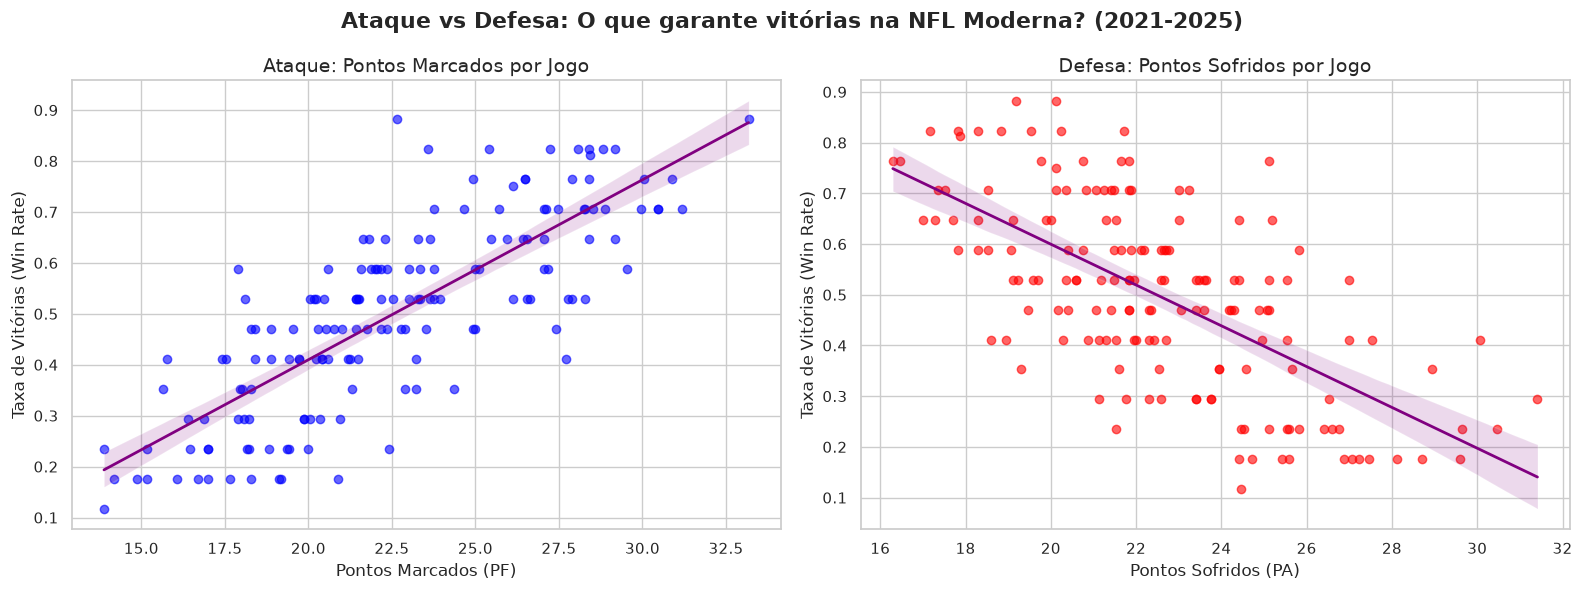


--- Correlação de Pearson ---
Correlação Ataque -> Vitórias: 0.799
Correlação Defesa -> Vitórias: -0.657 (Lembrando que quanto menor PA, melhor)

--- Correlação de Spearman ---
Ataque -> Vitórias: 0.811
Defesa -> Vitórias: -0.647


In [18]:
# configurando o estilo do gráfico 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ataque vs Defesa: O que garante vitórias na NFL Moderna? (2021-2025)', fontsize=16, fontweight='bold')

# Gráfico 1: Ataque (Pontos Feitos vs Win Rate)
sns.regplot(
    data=df_season_stats, 
    x='pontos_feitos_por_jogo', 
    y='win_rate', 
    ax=axes[0], 
    scatter_kws={'alpha':0.6, 'color':'blue'}, 
    line_kws={'color':'purple', 'linewidth':2}
)
axes[0].set_title('Ataque: Pontos Marcados por Jogo', fontsize=14)
axes[0].set_xlabel('Pontos Marcados (PF)')
axes[0].set_ylabel('Taxa de Vitórias (Win Rate)')

# Gráfico 2: Defesa (Pontos Sofridos vs Win Rate)
sns.regplot(
    data=df_season_stats, 
    x='pontos_sofridos_por_jogo', 
    y='win_rate', 
    ax=axes[1], 
    scatter_kws={'alpha':0.6, 'color':'red'}, 
    line_kws={'color':'purple', 'linewidth':2}
)
axes[1].set_title('Defesa: Pontos Sofridos por Jogo', fontsize=14)
axes[1].set_xlabel('Pontos Sofridos (PA)')
axes[1].set_ylabel('Taxa de Vitórias (Win Rate)')

plt.tight_layout()
plt.show()

# a prova matemática (Correlação de Pearson)
corr_ataque = df_season_stats['pontos_feitos_por_jogo'].corr(df_season_stats['win_rate'])
corr_defesa = df_season_stats['pontos_sofridos_por_jogo'].corr(df_season_stats['win_rate']) # esperado ser negativo

print("\n--- Correlação de Pearson ---")
print(f"Correlação Ataque -> Vitórias: {corr_ataque:.3f}")
print(f"Correlação Defesa -> Vitórias: {corr_defesa:.3f} (Lembrando que quanto menor PA, melhor)")

# (Correlação de Spearman)
corr_ataque_spearman = df_season_stats['pontos_feitos_por_jogo'].corr(df_season_stats['win_rate'], method='spearman')
corr_defesa_spearman = df_season_stats['pontos_sofridos_por_jogo'].corr(df_season_stats['win_rate'], method='spearman')

print("\n--- Correlação de Spearman ---")
print(f"Ataque -> Vitórias: {corr_ataque_spearman:.3f}")
print(f"Defesa -> Vitórias: {corr_defesa_spearman:.3f}")

- Olhando os gráficos de dispersão, dá pra ver que as intuições iniciais se provaram, quanto mais pontos marcados em um jogo, maior a chance de vencer, e quanto menos pontos sofridos em um jogo, maior a chance de vencer. Pode-se observar tendências gerais nos gráficos, apesar dos pontos não estarem condensados em cima da reta ideal em nenhum dos dois gráficos, o gráfico da relação entre ataque e vitória parece mais concentrado em relação ao de defesa, o que indica uma relação mais forte.

- O cálculo das correlações, tanto de Pearson quanto de Spearman, prova matematicamente oque era indicado nos gráficos: o ataque tem uma influencia mais forte do que a defesa pra definir quem ganha os jogos da temporada regular na NFL.

- Como exatamente o saldo de turnovers afeta a chance de vitória de um time em um jogo? Existe um ponto de não retorno?

In [19]:
# agrupando os turnovers cometidos por time em cada jogo
# somando as interceptações lançadas e os fumbles perdidos
df_stats['turnovers_cometidos'] = df_stats['passing_interceptions'].fillna(0) + df_stats['fumbles_lost_total'].fillna(0)

df_turnovers = df_stats.groupby(['game_id', 'team'])['turnovers_cometidos'].sum().reset_index()

# preparando a base de jogos (Mandante)
df_to = df_regular[['game_id', 'home_team', 'away_team', 'home_score', 'away_score']].copy()

# trazendo os turnovers do mandante
df_to = df_to.merge(df_turnovers, left_on=['game_id', 'home_team'], right_on=['game_id', 'team'], how='left')
df_to.rename(columns={'turnovers_cometidos': 'home_turnovers'}, inplace=True)
df_to.drop(columns=['team'], inplace=True)

# trazendo os turnovers do visitante
df_to = df_to.merge(df_turnovers, left_on=['game_id', 'away_team'], right_on=['game_id', 'team'], how='left')
df_to.rename(columns={'turnovers_cometidos': 'away_turnovers'}, inplace=True)
df_to.drop(columns=['team'], inplace=True)

# empilhando a perspectiva para cada time no jogo
# perspectiva do Mandante:
df_to_home = pd.DataFrame({
    'saldo_turnovers': df_to['away_turnovers'] - df_to['home_turnovers'], # Saldo = Roubos - Perdas
    'win': (df_to['home_score'] > df_to['away_score']).astype(int)
})

# perspectiva do Visitante:
df_to_away = pd.DataFrame({
    'saldo_turnovers': df_to['home_turnovers'] - df_to['away_turnovers'],
    'win': (df_to['away_score'] > df_to['home_score']).astype(int)
})

# juntando as duas visões
df_caos = pd.concat([df_to_home, df_to_away])

# calculando o Win Rate por Saldo de Turnovers
df_caos_stats = df_caos.groupby('saldo_turnovers').agg(
    jogos=('win', 'count'),
    vitorias=('win', 'sum')
).reset_index()

df_caos_stats['win_rate'] = (df_caos_stats['vitorias'] / df_caos_stats['jogos']) * 100

# limita a visão a saldos comuns (de -4 a +4) para não sujar o gráfico com jogos raros de 7 turnovers (outliers muito absurdos)
df_caos_stats = df_caos_stats[(df_caos_stats['saldo_turnovers'] >= -4) & (df_caos_stats['saldo_turnovers'] <= 4)]

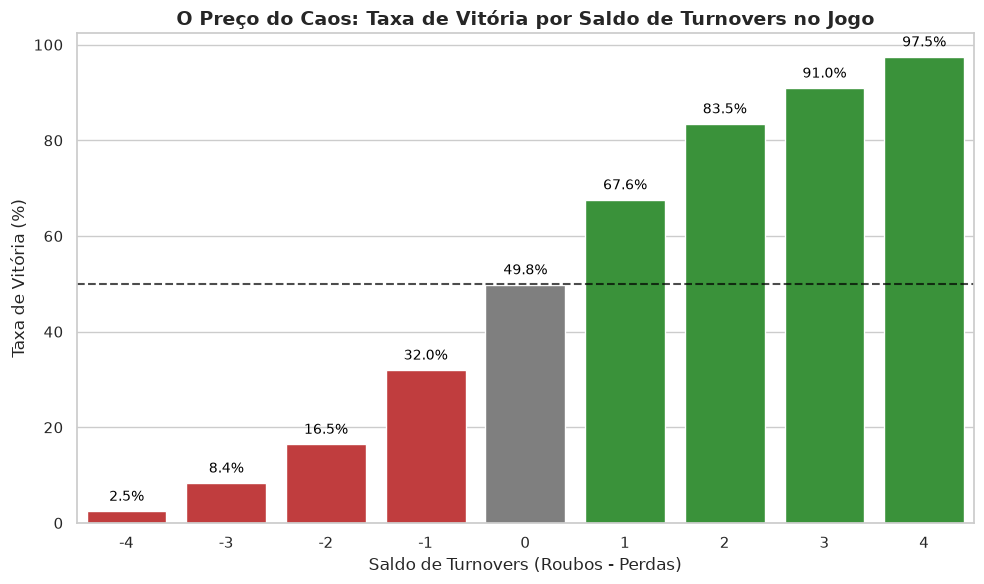

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# definindo cores dinâmicas: Vermelho para saldo negativo, Cinza para zero, Verde para positivo
cores = ['#d62728' if x < 0 else '#2ca02c' if x > 0 else '#7f7f7f' for x in df_caos_stats['saldo_turnovers']]

ax = sns.barplot(
    data=df_caos_stats, 
    x='saldo_turnovers', 
    y='win_rate', 
    palette=cores,
    hue='saldo_turnovers', # adicionado para silenciar o warning do Seaborn
    legend=False
)

plt.axhline(50, color='black', linestyle='--', alpha=0.7) # Linha de 50% (moeda para cima)

plt.title('O Preço do Caos: Taxa de Vitória por Saldo de Turnovers no Jogo', fontsize=14, fontweight='bold')
plt.xlabel('Saldo de Turnovers (Roubos - Perdas)', fontsize=12)
plt.ylabel('Taxa de Vitória (%)', fontsize=12)

# adicionando a % no topo de cada barra para clareza
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

- O Ponto Neutro (49.8%): Quando o saldo é zero, o jogo é literalmente um cara-ou-coroa. A decisão da vitória é totalmente delegada à eoutras estatísticas/fatores, já que nenhum time "deu de presente" posses extras ao adversário.

- A Gravidade do -1 (32.0%): Apenas uma perda de bola a mais já reduz a sua chance de vitória a menos de um terço.

- O Ponto de Não Retorno (-2): Se um time comete dois turnovers a mais que o oponente, a taxa de vitória desaba para míseros 16.5%. Isso significa que a cada 6 jogos nessa situação, o time perde 5. É estatisticamente uma sentença de morte na temporada regular da NFL moderna.

- A "Zebra" do -4 (2.5%): Ganhar cometendo 4 turnovers a mais é quase impossível. O fato de existir esse 2.5% reflete aqueles jogos bizarros que entram para a história.

- O que ganha mais jogos: ter um ganho massivo de Jardas por Jogada (YPP - times explosivos, passes longos) ou acumular muitas Jardas Totais por volume (ataques metódicos que mastigam o relógio e fazem dezenas de jogadas curtas)?

In [22]:
# agregando o volume e a eficiência por time em cada jogo
df_offense = df_stats.groupby(['game_id', 'team']).agg(
    pass_yds=('passing_yards', 'sum'),
    rush_yds=('rushing_yards', 'sum'),
    pass_att=('attempts', 'sum'),
    sacks=('sacks_suffered', 'sum'),
    rush_att=('carries', 'sum')
).reset_index()

# calculando as métricas finais
df_offense['total_yards'] = df_offense['pass_yds'] + df_offense['rush_yds']
df_offense['total_plays'] = df_offense['pass_att'] + df_offense['sacks'] + df_offense['rush_att']
df_offense['ypp'] = df_offense['total_yards'] / df_offense['total_plays']

# preparando a base de resultados dos jogos
df_eff = df_regular[['game_id', 'home_team', 'away_team', 'home_score', 'away_score']].copy()

# Perspectiva do Mandante
df_eff_home = df_eff.merge(df_offense, left_on=['game_id', 'home_team'], right_on=['game_id', 'team'])
df_eff_home['win'] = (df_eff_home['home_score'] > df_eff_home['away_score']).astype(int)

# Perspectiva do Visitante
df_eff_away = df_eff.merge(df_offense, left_on=['game_id', 'away_team'], right_on=['game_id', 'team'])
df_eff_away['win'] = (df_eff_away['away_score'] > df_eff_away['home_score']).astype(int)

# consolidando tudo
df_estilo_jogo = pd.concat([df_eff_home, df_eff_away])

# removendo possíveis valores nulos ou divisões por zero (jogos sem jogadas registradas)
df_estilo_jogo = df_estilo_jogo.dropna(subset=['ypp', 'total_yards'])

In [23]:
# Correlações (Impacto no Resultado do Jogo)
corr_yards_p = df_estilo_jogo['total_yards'].corr(df_estilo_jogo['win'], method='pearson')
corr_ypp_p = df_estilo_jogo['ypp'].corr(df_estilo_jogo['win'], method='pearson')

corr_yards_s = df_estilo_jogo['total_yards'].corr(df_estilo_jogo['win'], method='spearman')
corr_ypp_s = df_estilo_jogo['ypp'].corr(df_estilo_jogo['win'], method='spearman')

print(f"Impacto do Volume (Jardas Totais) na Vitória: Pearson[{corr_yards_p:.3f}] e Spearman[{corr_yards_s:.3f}]")
print(f"Impacto da Eficiência (YPP) na Vitória: Pearson[{corr_ypp_p:.3f}] e Spearman[{corr_ypp_s:.3f}]")

Impacto do Volume (Jardas Totais) na Vitória: Pearson[0.300] e Spearman[0.296]
Impacto da Eficiência (YPP) na Vitória: Pearson[0.263] e Spearman[0.261]


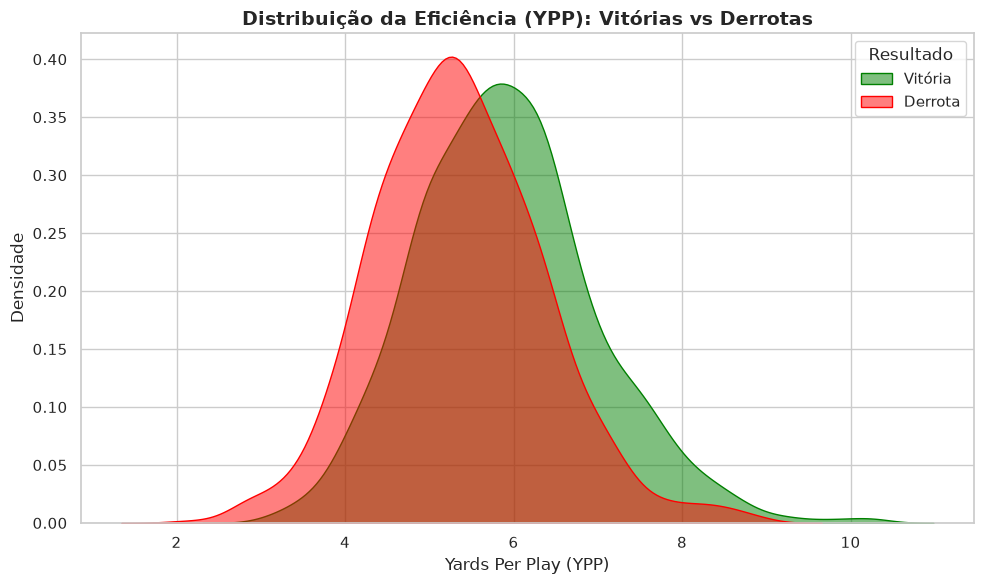

In [24]:
# distribuição de YPP em Vitórias vs Derrotas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_estilo_jogo[df_estilo_jogo['win'] == 1], x='ypp', fill=True, color='green', label='Vitória', alpha=0.5)
sns.kdeplot(data=df_estilo_jogo[df_estilo_jogo['win'] == 0], x='ypp', fill=True, color='red', label='Derrota', alpha=0.5)

plt.title('Distribuição da Eficiência (YPP): Vitórias vs Derrotas', fontsize=14, fontweight='bold')
plt.xlabel('Yards Per Play (YPP)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Resultado')

plt.tight_layout()
plt.show()

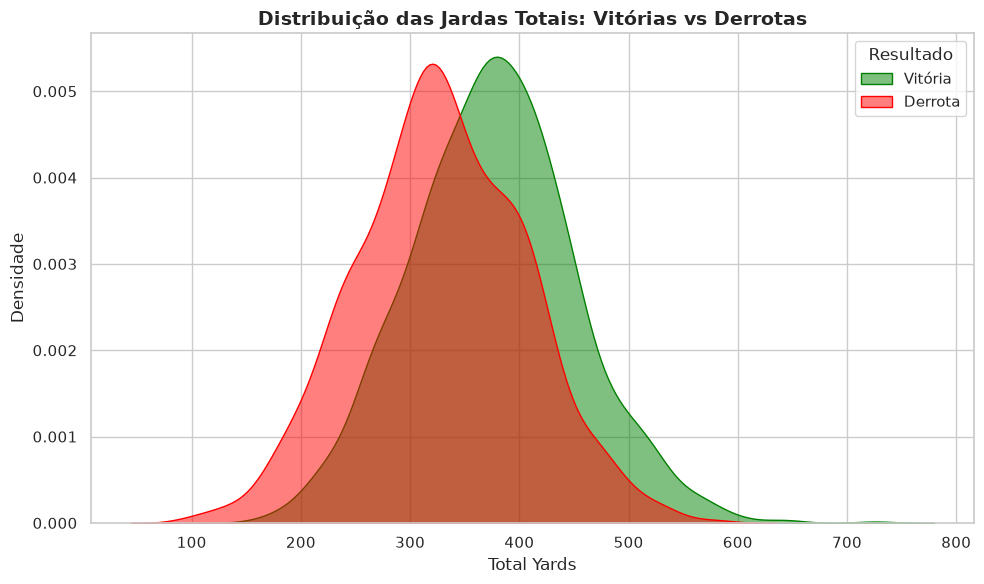

In [27]:
# distribuição de total yards em Vitórias vs Derrotas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_estilo_jogo[df_estilo_jogo['win'] == 1], x='total_yards', fill=True, color='green', label='Vitória', alpha=0.5)
sns.kdeplot(data=df_estilo_jogo[df_estilo_jogo['win'] == 0], x='total_yards', fill=True, color='red', label='Derrota', alpha=0.5)

plt.title('Distribuição das Jardas Totais: Vitórias vs Derrotas', fontsize=14, fontweight='bold')
plt.xlabel('Total Yards', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Resultado')

plt.tight_layout()
plt.show()

- Assim como indicam os valores bem baixos das correlações, os gráficos tanto de ypp quando de totais, apesar dos picos de fato serem distintos, a maior parte dos dados em ambos os gráficos está na sobreposição, onde vitórias e derrotas são estatisticamente indistinguíveis apenas por essas métricas.

- Isso expõe uma armadilha clássica do futebol americano conhecida como "Garbage Time" (tempo de lixo). Um time perdendo por três posses de bola no último quarto passa a lançar passes desesperadamente contra uma defesa que já recuou, focada apenas em gastar o relógio. O ataque derrotado vai acumular facilmente 400 jardas totais e inflar seu YPP, caindo no lado direito do gráfico de densidade, mesmo saindo com a derrota.

- Comparando a taxa de vitoria entre mandantes e visitantes, jogar em casa realmente é uma vantagem ou apenas uma narrativa?

In [29]:
# mapeando os resultados de cada jogo (ignorando empates raros para o win rate principal)
df_jogos_validos = df_jogos[df_jogos['home_score'] != df_jogos['away_score']].copy()

df_jogos_validos['home_win'] = (df_jogos_validos['home_score'] > df_jogos_validos['away_score']).astype(int)
df_jogos_validos['away_win'] = (df_jogos_validos['away_score'] > df_jogos_validos['home_score']).astype(int)

# agrupando por temporada
df_home_adv = df_jogos_validos.groupby('season').agg(
    total_games=('game_id', 'count'),
    home_wins=('home_win', 'sum'),
    away_wins=('away_win', 'sum')
).reset_index()

# calculando as taxas (%)
df_home_adv['home_win_rate'] = (df_home_adv['home_wins'] / df_home_adv['total_games']) * 100
df_home_adv['away_win_rate'] = (df_home_adv['away_wins'] / df_home_adv['total_games']) * 100

# calculando a Média Global
taxa_global_home = (df_home_adv['home_wins'].sum() / df_home_adv['total_games'].sum()) * 100
print(f"Taxa Histórica Global de Vitória do Mandante: {taxa_global_home:.1f}%")

Taxa Histórica Global de Vitória do Mandante: 54.6%


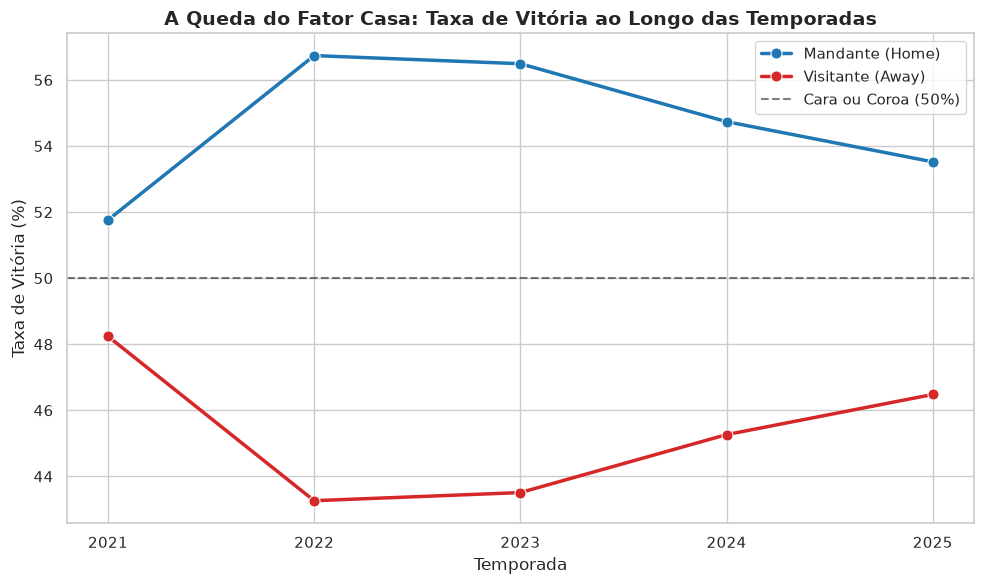

In [30]:
# visualização: a evolução do fator jogo em casa
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# linha dos Mandantes
sns.lineplot(
    data=df_home_adv, x='season', y='home_win_rate', 
    marker='o', label='Mandante (Home)', color='#1f77b4', linewidth=2.5, markersize=8
)
# linha dos Visitantes
sns.lineplot(
    data=df_home_adv, x='season', y='away_win_rate', 
    marker='o', label='Visitante (Away)', color='#d62728', linewidth=2.5, markersize=8
)

# linha neutra de 50%
plt.axhline(50, color='black', linestyle='--', alpha=0.5, label='Cara ou Coroa (50%)')

plt.title('A Queda do Fator Casa: Taxa de Vitória ao Longo das Temporadas', fontsize=14, fontweight='bold')
plt.xlabel('Temporada', fontsize=12)
plt.ylabel('Taxa de Vitória (%)', fontsize=12)

# garantindo que o eixo X mostre apenas anos inteiros
plt.xticks(df_home_adv['season']) 
plt.legend()

plt.tight_layout()
plt.show()

- A taxa global de vitória do mandante, dos ultimos 5 anos, 54.6%, apesar de não estar muito acima de 50%, só o fato de os visitantes absolutamente nunca terem tido uma taxa melhor que os mandantes, já diz/indica o bastante de que jogar em casa realmente é uma vantagem, e não é um mito.

- Aplicando algumas das perguntas que tentei responder até agora, pra jogos apenas dos playoff, pra verificar se o ambiente muda a análise:

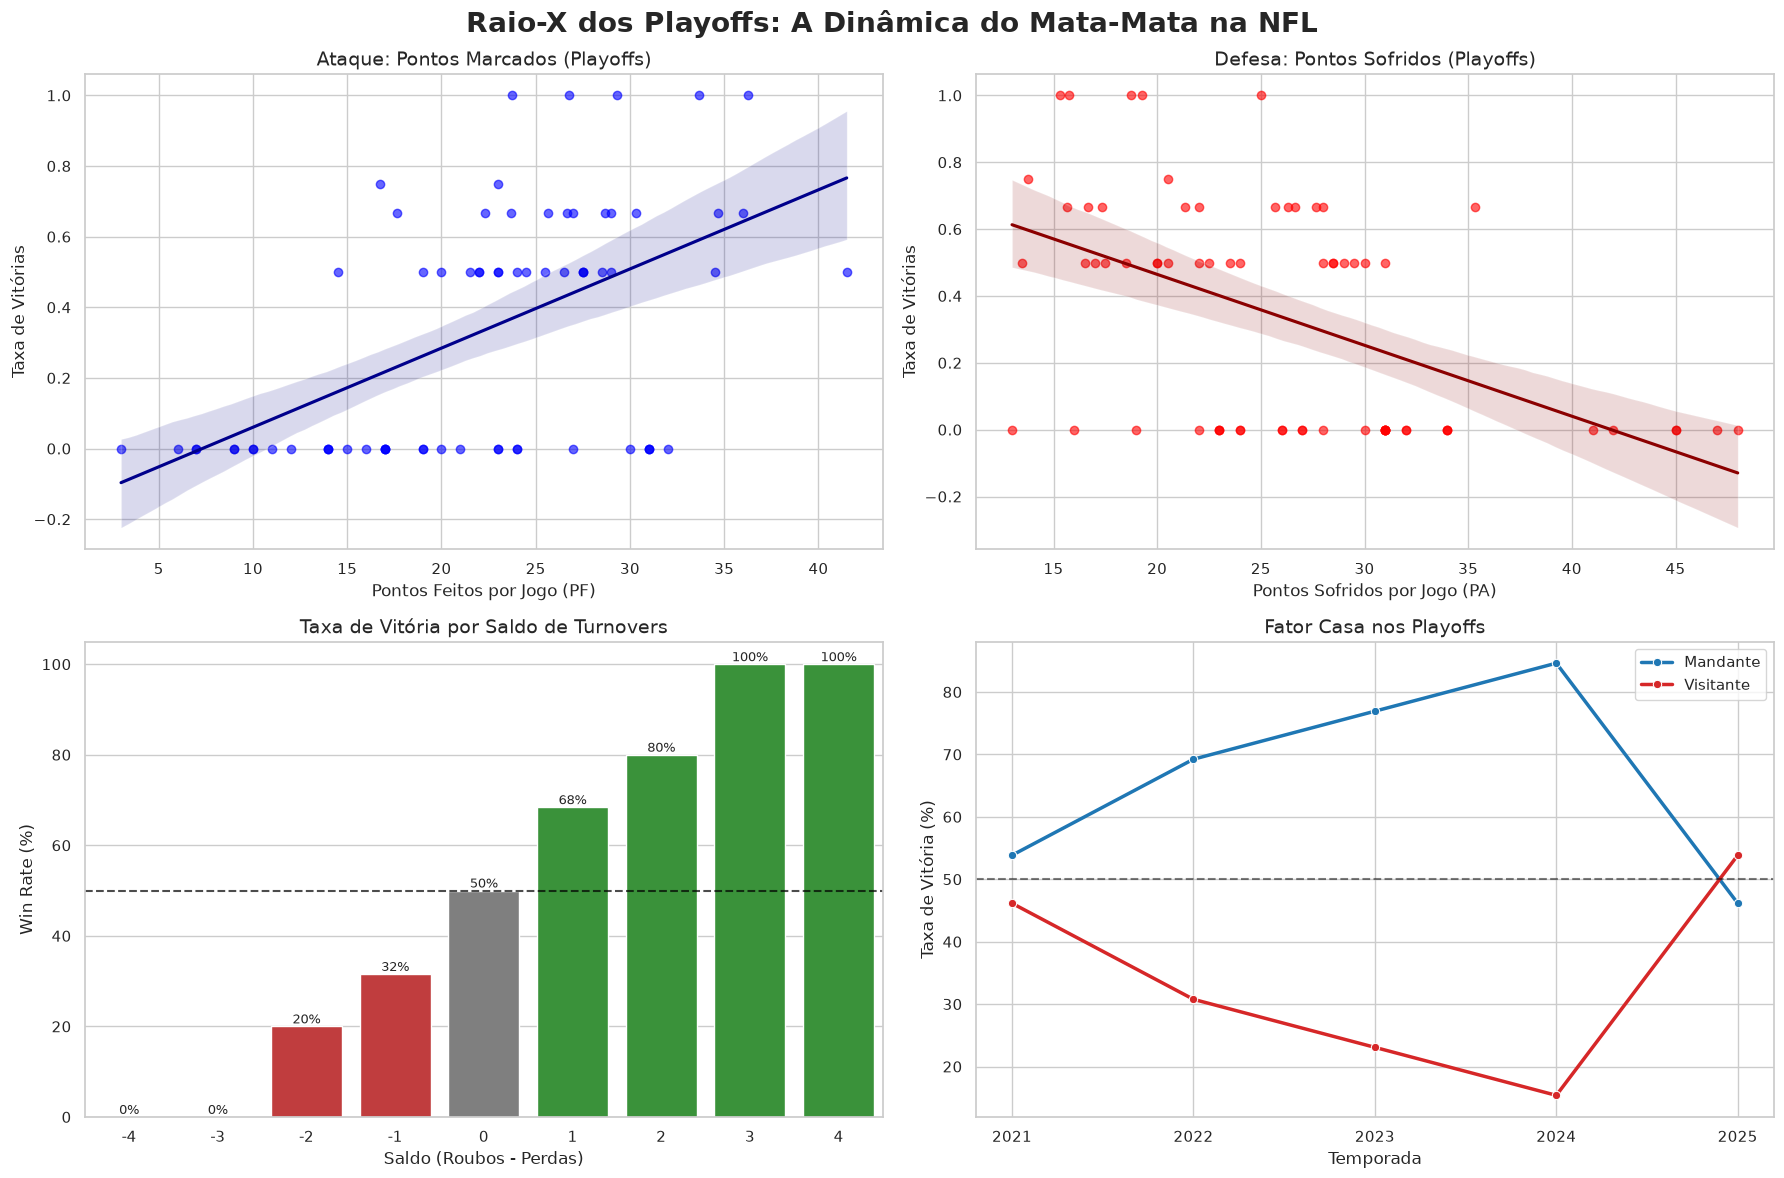


--- Correlações nos Playoffs ---
Ataque (PF) -> Vitórias (Pearson): 0.540
Defesa (PA) -> Vitórias (Pearson): -0.505 (Negativo é melhor)
Ataque (PF) -> Vitórias (Spearman): 0.514
Defesa (PA) -> Vitórias (Spearman): -0.516 (Negativo é melhor)
Taxa Global de Vitória do Mandante nos Playoffs: 66.2%


In [33]:
# excluindo Temporada Regular (REG) e Pré-temporada (PRE)
df_po = df_jogos[~df_jogos['game_type'].isin(['REG', 'PRE'])].copy()

# ==============================================================================

# --- A e B) Ataque vs Defesa (Win Rate por Time/Temporada) ---
df_home_po = df_po[['season', 'home_team', 'home_score', 'away_score']].copy()
df_home_po['win'] = (df_home_po['home_score'] > df_home_po['away_score']).astype(int)
df_home_po.rename(columns={'home_team': 'team', 'home_score': 'PF', 'away_score': 'PA'}, inplace=True)

df_away_po = df_po[['season', 'away_team', 'away_score', 'home_score']].copy()
df_away_po['win'] = (df_away_po['away_score'] > df_away_po['home_score']).astype(int)
df_away_po.rename(columns={'away_team': 'team', 'away_score': 'PF', 'home_score': 'PA'}, inplace=True)

df_season_stats_po = pd.concat([df_home_po, df_away_po]).groupby(['season', 'team']).agg(
    jogos=('win', 'count'), vitorias=('win', 'sum'),
    PF_mean=('PF', 'mean'), PA_mean=('PA', 'mean')
).reset_index()
df_season_stats_po['win_rate'] = df_season_stats_po['vitorias'] / df_season_stats_po['jogos']

# --- C) O Preço do Caos (Turnovers no Jogo) ---
df_turnovers_po = df_stats.groupby(['game_id', 'team'])['turnovers_cometidos'].sum().reset_index() 
df_to = df_po[['game_id', 'home_team', 'away_team', 'home_score', 'away_score']].merge(df_turnovers_po, left_on=['game_id', 'home_team'], right_on=['game_id', 'team'], how='left').rename(columns={'turnovers_cometidos': 'home_turnovers'}).drop(columns=['team'])
df_to = df_to.merge(df_turnovers_po, left_on=['game_id', 'away_team'], right_on=['game_id', 'team'], how='left').rename(columns={'turnovers_cometidos': 'away_turnovers'}).drop(columns=['team'])

df_caos_po = pd.concat([
    pd.DataFrame({'saldo_turnovers': df_to['away_turnovers'] - df_to['home_turnovers'], 'win': (df_to['home_score'] > df_to['away_score']).astype(int)}),
    pd.DataFrame({'saldo_turnovers': df_to['home_turnovers'] - df_to['away_turnovers'], 'win': (df_to['away_score'] > df_to['home_score']).astype(int)})
])
df_caos_stats_po = df_caos_po.groupby('saldo_turnovers').agg(jogos=('win', 'count'), vitorias=('win', 'sum')).reset_index()
df_caos_stats_po['win_rate'] = (df_caos_stats_po['vitorias'] / df_caos_stats_po['jogos']) * 100
df_caos_stats_po = df_caos_stats_po[(df_caos_stats_po['saldo_turnovers'] >= -4) & (df_caos_stats_po['saldo_turnovers'] <= 4)]

# --- D) Vantagem do Mandante ---
df_jogos_validos_po = df_po[df_po['home_score'] != df_po['away_score']].copy()
df_home_adv_po = df_jogos_validos_po.groupby('season').agg(
    total_games=('game_id', 'count'),
    home_wins=('home_score', lambda x: (x > df_jogos_validos_po.loc[x.index, 'away_score']).sum()),
    away_wins=('away_score', lambda x: (x > df_jogos_validos_po.loc[x.index, 'home_score']).sum())
).reset_index()
df_home_adv_po['home_win_rate'] = (df_home_adv_po['home_wins'] / df_home_adv_po['total_games']) * 100
df_home_adv_po['away_win_rate'] = (df_home_adv_po['away_wins'] / df_home_adv_po['total_games']) * 100

# ==============================================================================
#  O PAINEL DE VISUALIZAÇÃO 2x2
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Raio-X dos Playoffs: A Dinâmica do Mata-Mata na NFL', fontsize=20, fontweight='bold')

# [0, 0]: Ataque (Pontos Feitos)
sns.regplot(data=df_season_stats_po, x='PF_mean', y='win_rate', ax=axes[0, 0], scatter_kws={'alpha':0.6, 'color':'blue'}, line_kws={'color':'darkblue'})
axes[0, 0].set_title('Ataque: Pontos Marcados (Playoffs)', fontsize=14)
axes[0, 0].set_xlabel('Pontos Feitos por Jogo (PF)')
axes[0, 0].set_ylabel('Taxa de Vitórias')

# [0, 1]: Defesa (Pontos Sofridos)
sns.regplot(data=df_season_stats_po, x='PA_mean', y='win_rate', ax=axes[0, 1], scatter_kws={'alpha':0.6, 'color':'red'}, line_kws={'color':'darkred'})
axes[0, 1].set_title('Defesa: Pontos Sofridos (Playoffs)', fontsize=14)
axes[0, 1].set_xlabel('Pontos Sofridos por Jogo (PA)')
axes[0, 1].set_ylabel('Taxa de Vitórias')

# [1, 0]: O Preço do Caos (Turnovers) - Agora no canto inferior esquerdo
cores = ['#d62728' if x < 0 else '#2ca02c' if x > 0 else '#7f7f7f' for x in df_caos_stats_po['saldo_turnovers']]
sns.barplot(data=df_caos_stats_po, x='saldo_turnovers', y='win_rate', ax=axes[1, 0], palette=cores, hue='saldo_turnovers', legend=False)
axes[1, 0].axhline(50, color='black', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Taxa de Vitória por Saldo de Turnovers', fontsize=14)
axes[1, 0].set_xlabel('Saldo (Roubos - Perdas)')
axes[1, 0].set_ylabel('Win Rate (%)')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.0f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)

# [1, 1]: Vantagem do Mandante - Canto inferior direito
sns.lineplot(data=df_home_adv_po, x='season', y='home_win_rate', marker='o', label='Mandante', color='#1f77b4', linewidth=2.5, ax=axes[1, 1])
sns.lineplot(data=df_home_adv_po, x='season', y='away_win_rate', marker='o', label='Visitante', color='#d62728', linewidth=2.5, ax=axes[1, 1])
axes[1, 1].axhline(50, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Fator Casa nos Playoffs', fontsize=14)
axes[1, 1].set_xlabel('Temporada')
axes[1, 1].set_ylabel('Taxa de Vitória (%)')
axes[1, 1].set_xticks(df_home_adv_po['season'])

plt.tight_layout()
plt.show()

# --- AVALIAÇÃO MATEMÁTICA DOS PLAYOFFS ---
# Pearson (Relação Linear)
corr_ataque_po_pearson = df_season_stats_po['PF_mean'].corr(df_season_stats_po['win_rate'])
corr_defesa_po_pearson = df_season_stats_po['PA_mean'].corr(df_season_stats_po['win_rate']) 

# Spearman (Relação de Ranqueamento)
corr_ataque_po_spearman = df_season_stats_po['PF_mean'].corr(df_season_stats_po['win_rate'], method='spearman')
corr_defesa_po_spearman = df_season_stats_po['PA_mean'].corr(df_season_stats_po['win_rate'], method='spearman')

print("\n--- Correlações nos Playoffs ---")
print(f"Ataque (PF) -> Vitórias (Pearson): {corr_ataque_po_pearson:.3f}")
print(f"Defesa (PA) -> Vitórias (Pearson): {corr_defesa_po_pearson:.3f} (Negativo é melhor)")
print(f"Ataque (PF) -> Vitórias (Spearman): {corr_ataque_po_spearman:.3f}")
print(f"Defesa (PA) -> Vitórias (Spearman): {corr_defesa_po_spearman:.3f} (Negativo é melhor)")

# Imprimir Estatística Rápida da Vantagem do Mandante
print(f"Taxa Global de Vitória do Mandante nos Playoffs: {(df_home_adv_po['home_wins'].sum() / df_home_adv_po['total_games'].sum()) * 100:.1f}%")

- O equilíbrio de forças (Ataque vs. Defesa): na temporada regular, o ataque dita o ritmo com uma dominância clara. No entanto, nos playoffs, os coeficientes de Pearson e Spearman convergem (0.540 para o ataque contra -0.505/-0.516 para a defesa). Isso indica que, no mata-mata, as margens de erro desaparecem. Enfrentando apenas os melhores times da liga, o equilíbrio entre as unidades se torna obrigatório. Um ataque estrondoso sem defesa é neutralizado, assim como uma defesa de elite não sobrevive se o ataque for fraco. Os dados mostram que, para avançar, a exigência de eficiência recai simetricamente sobre os dois lados da bola.

- Em relação aos turnovers, enquanto na temporada regular ainda existiam pequenas probabilidades perdidas (2.5% para -4, e 8.4% para -3), nos playoffs a barra de -3 e -4 desaba para 0%. Cometer três ou quatro turnovers a mais que o adversário em jogo único significa eliminação matemática garantida. Por outro lado, as porcentagens quando o saldo é de -2 aumentou um pouco para 20%, e, curiosamente, a porcentagem do saldo de -1 se manteve exatamente igual em 32%.

- A explosão do fator casa: enquanto na temporada regular a vantagem de jogar em casa flutuava em torno de uma média histórica de 54.6%, nos playoffs o número salta agressivamente para 66.2%. Jogar em casa em janeiro significa torcida lotada pressionando em momentos críticos, estádios abertos com frio extremo ou neve contra times acostumados ao calor, e descanso mais igualitário, sem viagens longas.